
# Clustering Analysis

### 목표
- 전처리된 데이터를 기반으로 직원 유형 분석
- PCA를 활용한 차원 축소 및 시각화
- KMeans 기반 군집화 수행
- 각 군집의 특징 해석
- 즉, 업무환경 및 조직문화 관련 feature를 기반으로 
  유사한 특성을 가지는 직원 그룹 분석

### 고려사항
1. 불필요하게 많은 one-hot feature 제거
2. 핵심 업무환경 feature만 선택
3. PCA explained variance 개선 시도
4. Cluster 해석 가능성 강화
5. 핵심 feature 중심 cluster summary 생성



In [95]:

# =====================================================
# 1. Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

plt.rcParams["figure.figsize"] = (8, 6)


In [96]:

# =====================================================
# 2. Load Dataset

df = pd.read_csv("preprocessed_survey.csv")

print("===== DATA SHAPE =====")
print(df.shape)

print("\n===== HEAD =====")
print(df.head())


===== DATA SHAPE =====
(1259, 72)

===== HEAD =====
        Age  treatment  Gender_Female  Gender_Male  Gender_Other  \
0  0.351852          1            1.0          0.0           0.0   
1  0.481481          0            0.0          1.0           0.0   
2  0.259259          0            0.0          1.0           0.0   
3  0.240741          1            0.0          1.0           0.0   
4  0.240741          0            0.0          1.0           0.0   

   self_employed_No  self_employed_Yes  family_history_No  family_history_Yes  \
0               1.0                0.0                1.0                 0.0   
1               1.0                0.0                1.0                 0.0   
2               1.0                0.0                1.0                 0.0   
3               1.0                0.0                0.0                 1.0   
4               1.0                0.0                1.0                 0.0   

   work_interfere_Never  ...  mental_vs_physical_No 


## 일부 feature만 선택한 이유

전체 데이터셋을 통한 clustering에서는:
- 70개 이상의 one-hot feature 사용
- PCA explained variance가 매우 낮음
- cluster 해석 어려움

따라서
- 업무환경과 관련된 핵심 feature만 선택
- clustering 해석 가능성 강화


## Treatment feature 제거 이유

- treatment는 classification의 target variable 성격이 강함
- Clustering은 unsupervised learning이므로,
직원들의 업무환경 및 조직문화 특성만을 기반으로
유사한 그룹을 찾기 위함

In [97]:

# =====================================================
# 3. Select Important Features

selected_columns = [

    "Age",

    "family_history_Yes",

    "work_interfere_Never",
    "work_interfere_Sometimes",
    "work_interfere_Often",

    "benefits_Yes",

    "care_options_Yes",

    "anonymity_Yes",

    "leave_Somewhat easy",
    "leave_Very easy",

    "supervisor_Yes",

    "coworkers_Yes"

]

cluster_df = df[selected_columns]

print("===== SELECTED FEATURES =====")
print(cluster_df.head())

print("\n===== FEATURE COUNT =====")
print(cluster_df.shape[1])


===== SELECTED FEATURES =====
        Age  family_history_Yes  work_interfere_Never  \
0  0.351852                 0.0                   0.0   
1  0.481481                 0.0                   0.0   
2  0.259259                 0.0                   0.0   
3  0.240741                 1.0                   0.0   
4  0.240741                 0.0                   1.0   

   work_interfere_Sometimes  work_interfere_Often  benefits_Yes  \
0                       0.0                   1.0           1.0   
1                       0.0                   0.0           0.0   
2                       0.0                   0.0           0.0   
3                       0.0                   1.0           0.0   
4                       0.0                   0.0           1.0   

   care_options_Yes  anonymity_Yes  leave_Somewhat easy  leave_Very easy  \
0               0.0            1.0                  1.0              0.0   
1               0.0            0.0                  0.0              0.0

In [98]:

# =====================================================
# 4. Feature Scaling

scaler = StandardScaler()

scaled_data = scaler.fit_transform(cluster_df)

print("===== SCALED DATA SHAPE =====")
print(scaled_data.shape)


===== SCALED DATA SHAPE =====
(1259, 12)



## PCA (Principal Component Analysis)

목적:
- 고차원 데이터를 2차원으로 축소
- Cluster visualization
- 데이터 분산 최대한 유지

개선 사항:
- 초기 전체 데이터셋을 활용한 clustering에서는
  explaind variance가 0.148로 PCA 설명력이 매우 낮았음
- 이후 일부 핵심 feature만 선택한 결과 0.302로 개선됨
- 따라서 핵심 업무환경 관련 feature만 선택하여 clustering 품질과 해석 가능성을 개선함


In [99]:

# =====================================================
# 5. PCA

pca = PCA(n_components=2)

pca_data = pca.fit_transform(scaled_data)

print("===== PCA SHAPE =====")
print(pca_data.shape)

print("\n===== EXPLAINED VARIANCE RATIO =====")
print(pca.explained_variance_ratio_)

print("\n===== TOTAL EXPLAINED VARIANCE =====")
print(np.sum(pca.explained_variance_ratio_))


===== PCA SHAPE =====
(1259, 2)

===== EXPLAINED VARIANCE RATIO =====
[0.16581908 0.13661297]

===== TOTAL EXPLAINED VARIANCE =====
0.3024320475535962


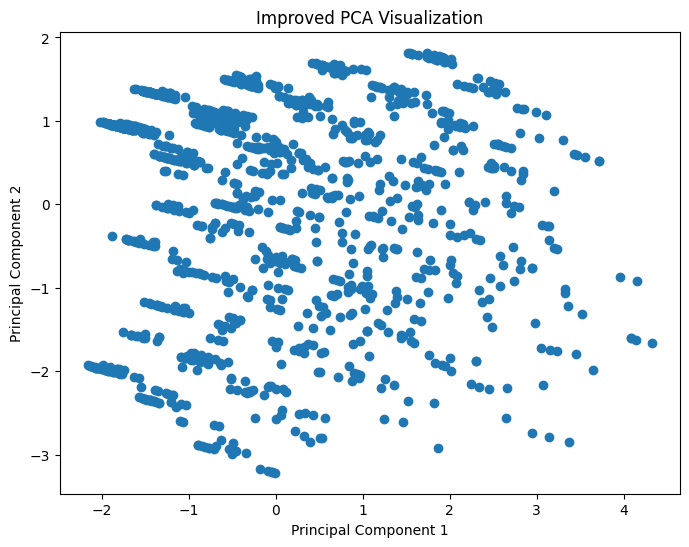

In [ ]:

# =====================================================
# 6. PCA Visualization

plt.scatter(
    pca_data[:, 0],
    pca_data[:, 1]
)

plt.title("PCA Visualization")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()



## Elbow Method

목적:
- 적절한 cluster 개수 탐색
- inertia 감소 추이 확인 (cluster 개수를 늘릴 때 얼마나 clustering이 좋아지는가?)


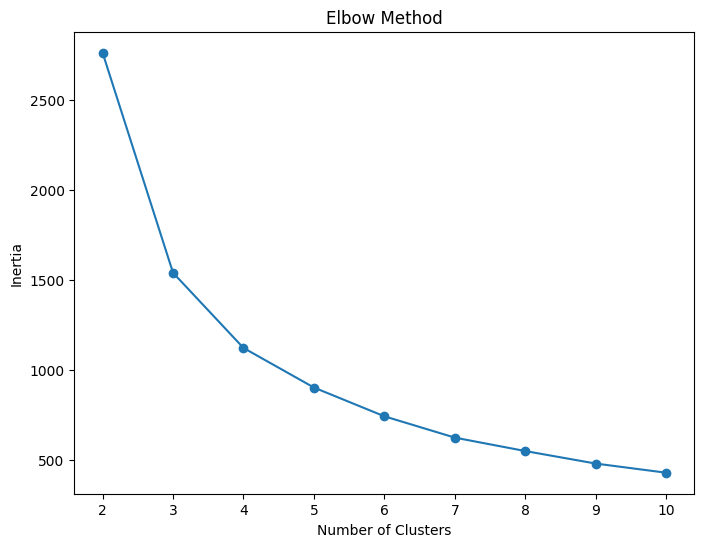

In [101]:

# =====================================================
# 7. Elbow Method

inertia_values = []

k_range = range(2, 11)

for k in k_range:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(pca_data)

    inertia_values.append(kmeans.inertia_)

plt.plot(
    k_range,
    inertia_values,
    marker='o'
)

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

plt.show()



## KMeans Clustering

Elbow Method 결과를 기반으로 한다면 k=3이 맞으나,
clustering 분석 결과가 모호하게 나와서 k=2로 설정함


In [102]:

# =====================================================
# 8. Apply KMeans

kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(pca_data)

cluster_df["Cluster"] = cluster_labels

print("===== CLUSTER COUNTS =====")
print(cluster_df["Cluster"].value_counts())

score = silhouette_score(pca_data, cluster_labels)

print("\n===== SILHOUETTE SCORE =====")
print(score)


===== CLUSTER COUNTS =====
Cluster
1    784
0    475
Name: count, dtype: int64

===== SILHOUETTE SCORE =====
0.3810129701981751


C:\Users\hyukj\AppData\Local\Temp\ipykernel_4128\2389171726.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cluster_df["Cluster"] = cluster_labels


## Treatment feature 추가 및 분석
Clustering 이후, cluster별 특성 비교를 위해 사후 분석 단계에서만 사용함

C:\Users\hyukj\AppData\Local\Temp\ipykernel_4128\3584405148.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cluster_df["treatment"] = df["treatment"]



===== TREATMENT RATIO BY CLUSTER =====
treatment         0         1
Cluster                      
0          0.315789  0.684211
1          0.602041  0.397959


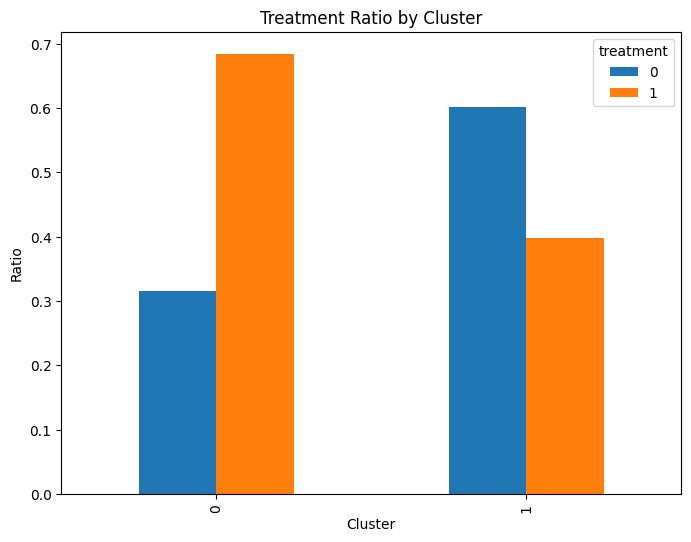

In [103]:
# =====================================================
# 8-1. Treatment Analysis by Cluster

cluster_df["treatment"] = df["treatment"]

treatment_summary = pd.crosstab(

    cluster_df["Cluster"],
    cluster_df["treatment"],

    normalize='index'

)

print("\n===== TREATMENT RATIO BY CLUSTER =====")
print(treatment_summary)

treatment_summary.plot(
    kind='bar'
)

plt.title("Treatment Ratio by Cluster")
plt.ylabel("Ratio")

plt.show()

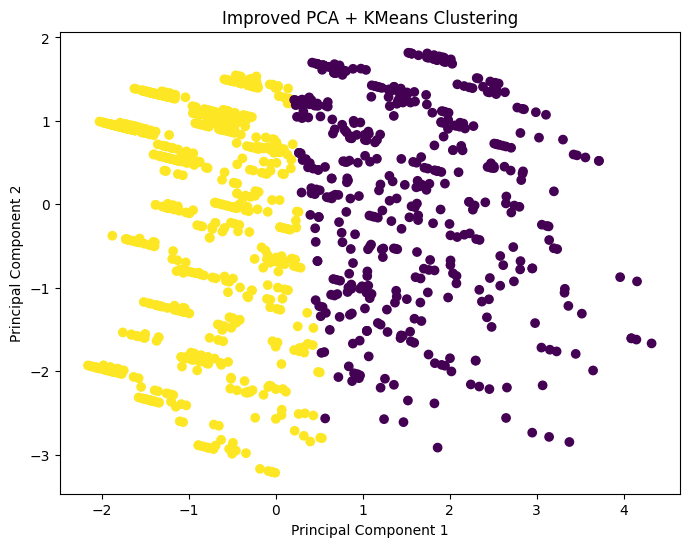

In [ ]:

# =====================================================
# 9. Cluster Visualization

plt.scatter(
    pca_data[:, 0],
    pca_data[:, 1],
    c=cluster_labels
)

plt.title("PCA + KMeans Clustering")

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()



## Cluster Interpretation

핵심 feature 중심으로 clustering:
- 지원 환경 우수 그룹
- 지원 환경 부족 그룹


In [105]:

# =====================================================
# 10. Cluster Summary

cluster_summary = cluster_df.groupby("Cluster").mean()

print("===== CLUSTER SUMMARY =====")
print(cluster_summary)


===== CLUSTER SUMMARY =====
              Age  family_history_Yes  work_interfere_Never  \
Cluster                                                       
0        0.283197            0.530526              0.090526   
1        0.246835            0.306122              0.216837   

         work_interfere_Sometimes  work_interfere_Often  benefits_Yes  \
Cluster                                                                 
0                        0.581053              0.155789      0.732632   
1                        0.577806              0.089286      0.164541   

         care_options_Yes  anonymity_Yes  leave_Somewhat easy  \
Cluster                                                         
0                0.764211       0.667368             0.267368   
1                0.103316       0.073980             0.177296   

         leave_Very easy  supervisor_Yes  coworkers_Yes  treatment  
Cluster                                                             
0               0.271579   

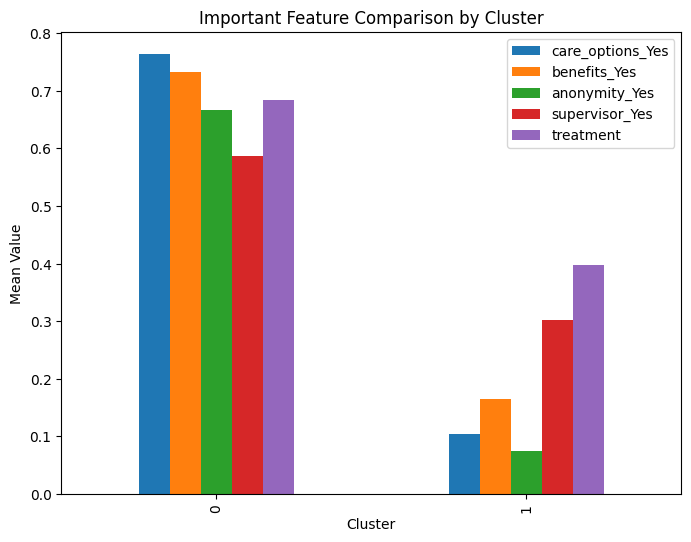

In [106]:

# =====================================================
# 11. Visualization of Important Features

important_features = [
    
    "care_options_Yes",
    "benefits_Yes",
    "anonymity_Yes",
    "supervisor_Yes",
    "treatment"

]

cluster_summary[important_features].plot(
    kind='bar'
)

plt.title("Important Feature Comparison by Cluster")
plt.ylabel("Mean Value")

plt.show()



## Cluster 0 — 정신 건강 지원 환경 우수 그룹
### 특징
- benefits 높음
- care_options 매우 높음
- anonymity 매우 높음
- supervisor support 높음
- coworkers support 높음
- treatment 비율 높음

### 해석
이 그룹은 조직 차원의 정신 건강 지원 제도가 비교적 잘 구축되어 있으며, 상사 및 동료와의 소통 환경도 양호한 특성을 보임

특히 anonymity, care_options, benefits 값이 높게 나타나 정신 건강과 관련된 지원 체계 및 심리적 안전성이 상대적으로 높은 업무환경 그룹으로 해석할 수 있음

또한 treatment 경험 비율 역시 상대적으로 높게 나타나, 지원 환경과 치료 접근 경험 사이의 연관 가능성을 확인할 수 있음

## Cluster 1 — 정신 건강 지원 환경 부족 그룹
### 특징
- work_interfere_Sometimes 높음
- benefits 매우 낮음
- care_options 매우 낮음
- anonymity 매우 낮음
- supervisor support 낮음
- coworkers support 낮음
- treatment 비율 낮음
### 해석
이 그룹은 정신 건강 문제가 업무에 일정 수준 영향을 주고 있음에도 불구하고, 조직 차원의 지원 환경은 부족한 특성을 보임

특히 benefits, care_options, anonymity와 같은 정신 건강 지원 관련 feature가 전반적으로 낮게 나타났으며, 상사 및 동료와의 심리적 안전성 역시 상대적으로 낮은 경향을 보임

또한 treatment 경험 비율 역시 상대적으로 낮게 나타나, 조직 지원 환경과 치료 경험 사이의 패턴 및 연관 가능성을 확인할 수 있음


In [ ]:

# =====================================================
# 12. Save Cluster Result

cluster_df.to_csv("cluster_result.csv", index=False)

print("===== CLUSTERING RESULT SAVED =====")


===== IMPROVED CLUSTER RESULT SAVED =====
